In [1]:
import os
import sys

from torch.optim import Adam

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

In [2]:
df_x_1, df_y_1 = read_dataset(stage='regression')
df_x_2, df_y_2 = read_dataset(stage='regression', discarded=True)
df_x_1['domain'] = 1
df_x_2['domain'] = 2
df_x = pd.concat([df_x_1, df_x_2], ignore_index=True)
df_y = pd.concat([df_y_1, df_y_2], ignore_index=True)

In [3]:
pyKAN: PHMNetwork = PyKAN([[len(df_x_1.columns) - 1, 0], [5, 0], [2, 0]], 'regression', grid_size=20, device='cpu')

checkpoint directory created: ./model
saving model version 0.0


## IDL 1 ($np \ge ng$)

In [4]:
trainset, validset, testset, normalizations = split_dataset(df_x, df_y['trq_margin'], 0.75,
                                                            standardize_y=False, group_by='domain')

In [5]:
train_losses, valid_losses, test_losses = {}, {}, {}
for domain in [1, 2]:
    def test():
        metrics = pyKAN.test(testset)
        test_losses[domain].append(metrics['test_loss'])


    test_losses[domain] = []
    train_losses[domain], valid_losses[domain] = (
        pyKAN.fit(trainset[domain], validset[domain], Adam(pyKAN.parameters(), lr=0.05), epochs=15, batch_size=2048,
                  prefix=f'IDL_{domain}', callback=test))
    pyKAN.save(f'IDL_{domain}')
#     Forse devi rimettere la loss

100%|██████████| 12/12 [00:01<00:00,  9.18it/s]


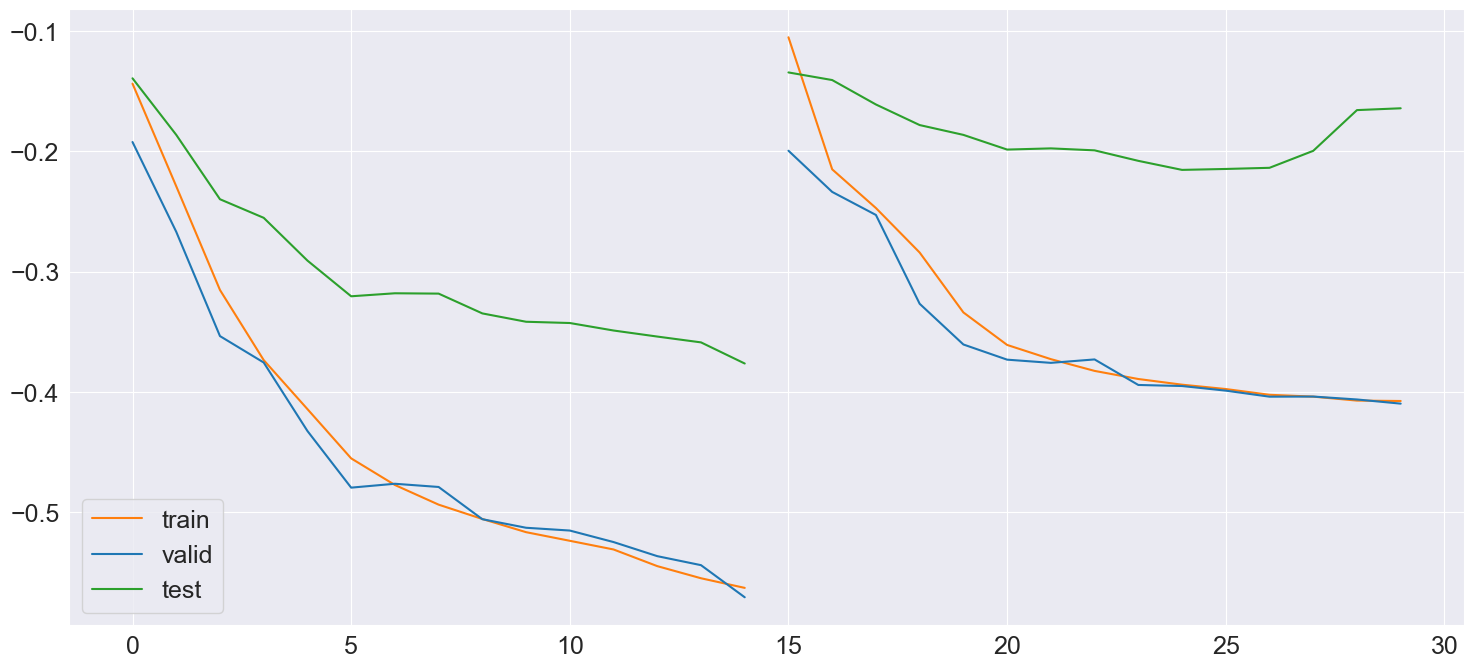

In [6]:
plt.figure(figsize=(18, 8))
plt.plot(train_losses[1], label='train', color='tab:orange')
plt.plot(range(len(train_losses[1]), 2 * len(train_losses[1])), train_losses[2], color='tab:orange')

plt.plot(valid_losses[1], label='valid', color='tab:blue')
plt.plot(range(len(valid_losses[1]), 2 * len(valid_losses[1])), valid_losses[2], color='tab:blue')

plt.plot(test_losses[1], label='test', color='tab:green')
plt.plot(range(len(test_losses[1]), 2 * len(test_losses[1])), test_losses[2], color='tab:green')

plt.legend()
plt.show()

In [ ]:
pyKAN.plot(scale=1.25, in_vars=list(map(to_latex, df_x_2.columns)))